## __Embeddings Benchmark for HVAC equipments__

This notebook aims to show a working approach for refining an embedding generator for images. We are going to begin with CNN based backbones.

__Limitations:__
- Embeddings generated by Mobilenet architecture
- Image based model (one input - one output) no multimodal models tested here (GPT4, CLIP, etc)

Found 1 categories: ['vrf']
vrf: 8 images


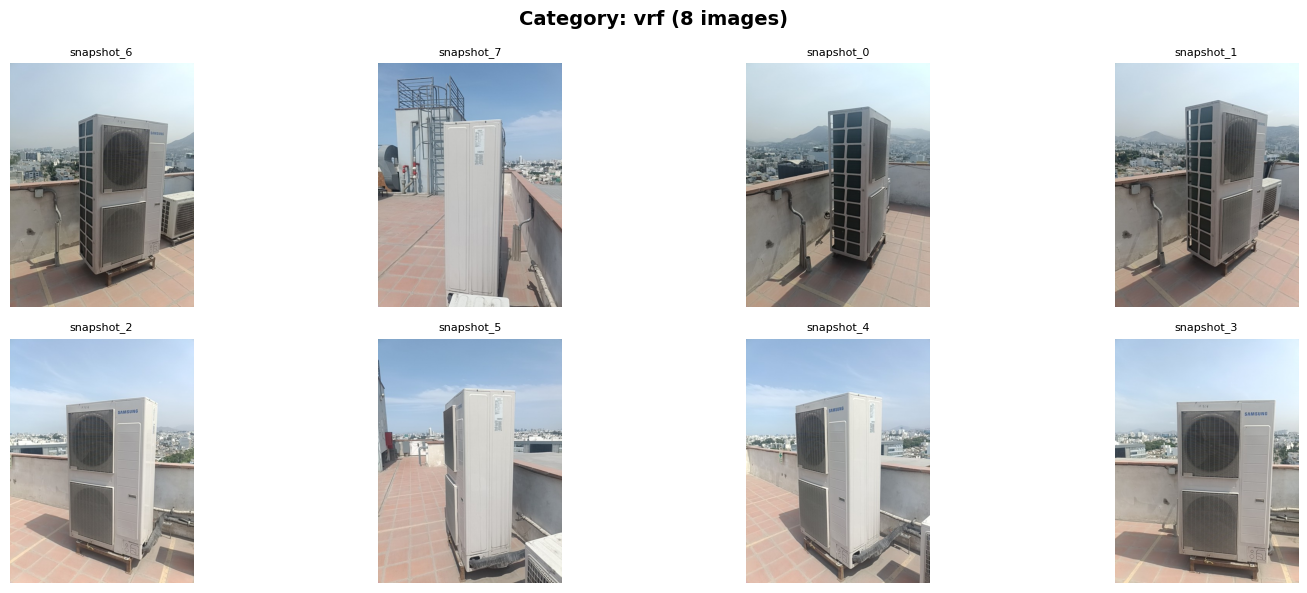

In [1]:
from utils import display_assets_images

# Display all images from assets folder
display_assets_images("assets/")

## __Generating embeddings with Mobilenetv3__

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:01<00:00, 17.9MB/s]


Generating embeddings with MobileNetV3 Large...
EMBEDDING STATISTICS

VRF:
  Samples: 1
  Dimensions: 960
  Shape: (1, 960)
  Mean: 0.2016
  Std: 0.4483
  Min: -0.2357
  Max: 3.6929


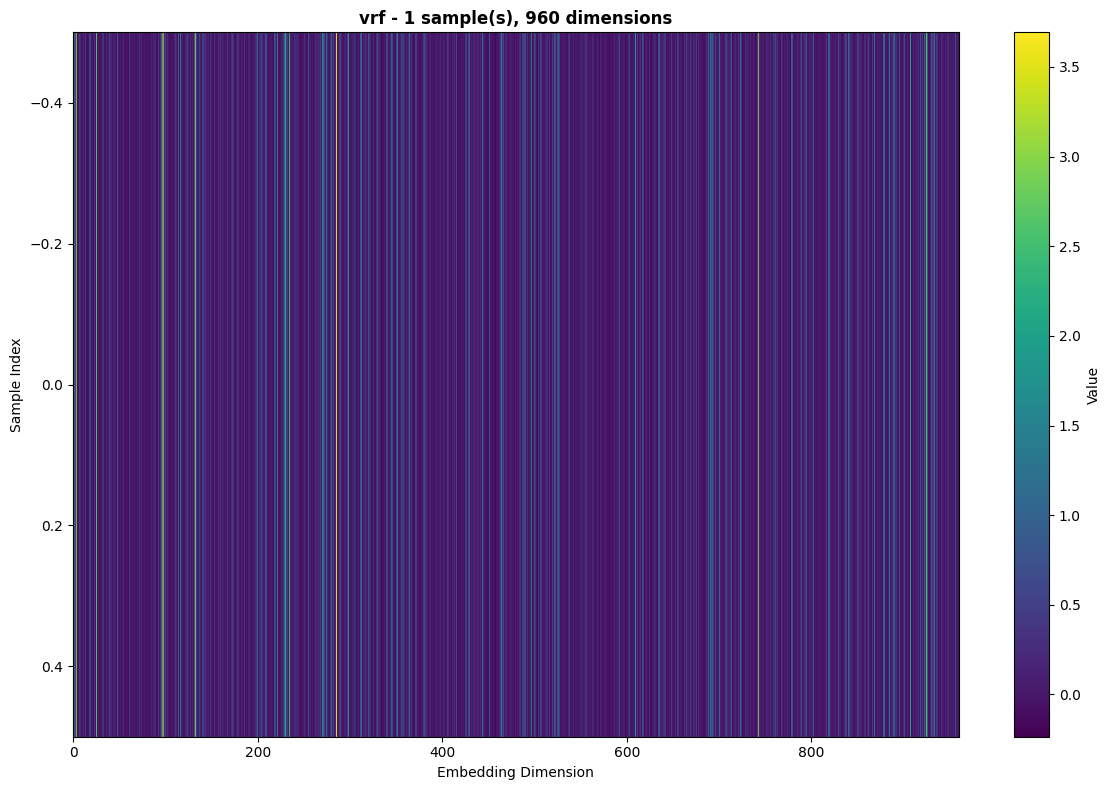


Images used for embeddings:
vrf: ['/workspace/assets/vrf/snapshot_5.jpg']


In [3]:
from utils import MobileNetV3Embeddings, plot_embeddings, print_embedding_stats

# Initialize MobileNetV3 Large for embeddings
embedder = MobileNetV3Embeddings(model_size='large', pretrained=True)

# Generate embeddings from assets folder (1 sample per class)
print("Generating embeddings with MobileNetV3 Large...")
embeddings, image_paths = embedder.get_embeddings_from_folder("assets/", sample_per_class=1)

# Print embedding statistics
print_embedding_stats(embeddings)

# Plot embeddings
plot_embeddings(embeddings)

# Show which images were used
print("\nImages used for embeddings:")
for category, paths in image_paths.items():
    print(f"{category}: {paths}")

## __MobileNetv3 + Segmentation (DeepLabv3)__

In [8]:
import torch
import torchvision
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import functional as F
import numpy as np
from PIL import Image
import os

In [3]:
# 3. MODEL
num_classes = 21  # YOUR NUMBER OF CLASSES (including background)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = deeplabv3_mobilenet_v3_large(
    weights='DEFAULT',  # COCO pre-trained
    num_classes=num_classes,
    aux_loss=True      # auxiliary loss for better training
).to(device)


In [4]:
# 8. EXTRACT BACKBONE AFTER TRAINING (different embeddings!)
backbone = model.backbone
torch.save(backbone.state_dict(), 'backbone_segmentation_deeplabv3_coco.pth')

1. BACKBONE ORIGINAL (COCO (20) pre-trained)
Downloading: "https://download.pytorch.org/models/deeplabv3_mobilenet_v3_large-fc3c493d.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_mobilenet_v3_large-fc3c493d.pth


100%|██████████| 42.3M/42.3M [00:01<00:00, 23.7MB/s]


EMBEDDING STATISTICS

EMBEDDINGS:
  Samples: 1
  Dimensions: 188160
  Shape: (1, 188160)
  Mean: 0.1487
  Std: 0.7691
  Min: -0.3750
  Max: 12.0904
  First 10 values: [2.592378   2.889656   1.557292   3.4754767  2.7365446  1.2336953
 1.1500864  1.8607448  0.37093133 1.46436   ]


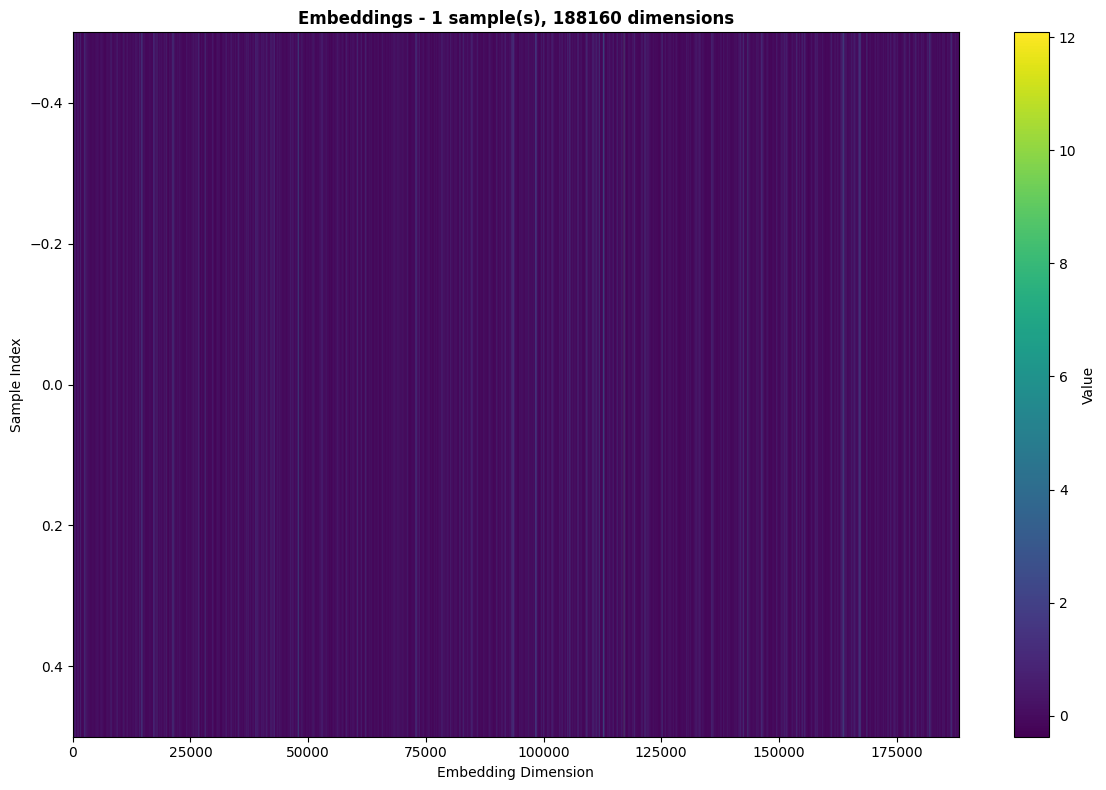


2. BACKBONE ENTRENADO (Fine-tuned en segmentación)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 34.6MB/s]


EMBEDDING STATISTICS

EMBEDDINGS:
  Samples: 1
  Dimensions: 188160
  Shape: (1, 188160)
  Mean: 0.1487
  Std: 0.7691
  Min: -0.3750
  Max: 12.0904
  First 10 values: [2.592378   2.889656   1.557292   3.4754767  2.7365446  1.2336953
 1.1500864  1.8607448  0.37093133 1.46436   ]


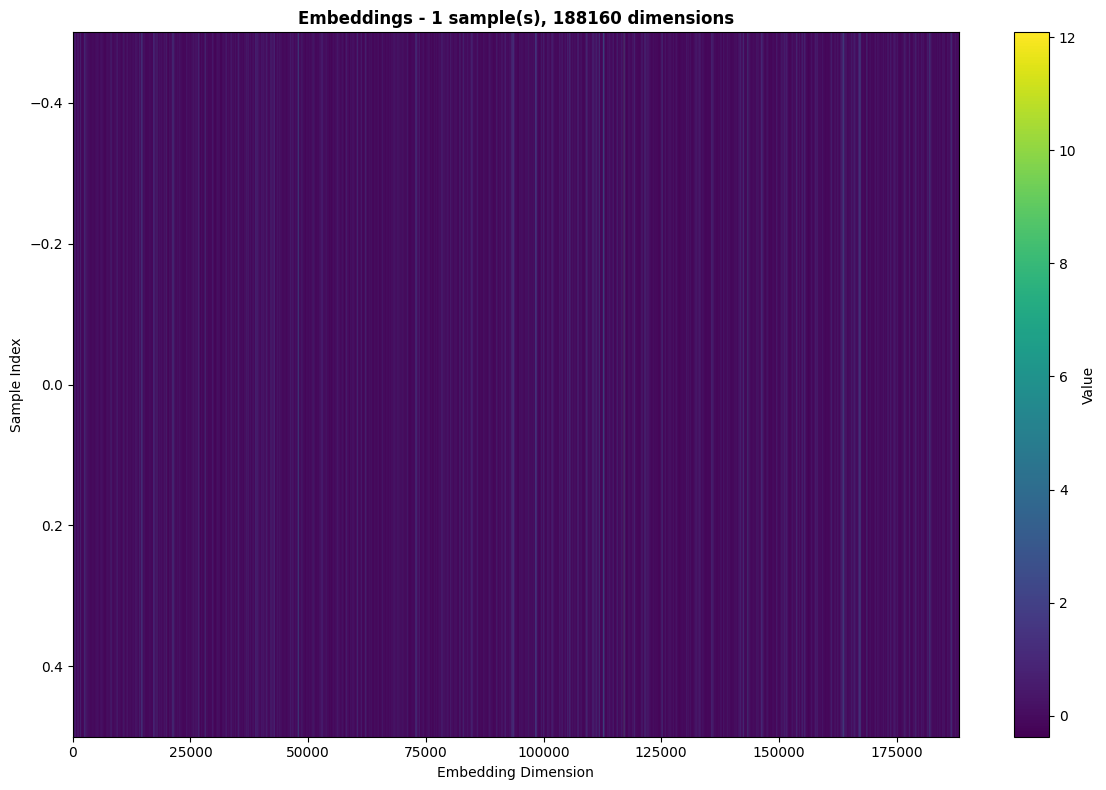


3. COMPARACIÓN DE EMBEDDINGS (MISMA IMAGEN)

Embedding shape: (188160,)

Primeros 20 valores - BACKBONE ORIGINAL:
[2.592378   2.889656   1.557292   3.4754767  2.7365446  1.2336953
 1.1500864  1.8607448  0.37093133 1.46436    0.89418525 0.5728177
 0.77976394 0.494707   0.5083861  0.17244062 0.18115805 1.2574373
 1.0458932  0.0641872 ]

Primeros 20 valores - BACKBONE ENTRENADO:
[2.592378   2.889656   1.557292   3.4754767  2.7365446  1.2336953
 1.1500864  1.8607448  0.37093133 1.46436    0.89418525 0.5728177
 0.77976394 0.494707   0.5083861  0.17244062 0.18115805 1.2574373
 1.0458932  0.0641872 ]

DIFERENCIA (trained - original):
  Media de diferencia: 0.000000
  Std de diferencia: 0.000000
  Máxima diferencia: 0.000000
  Mínima diferencia: 0.000000
  ¿Son idénticos? True


In [1]:
import torch
import torchvision
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
from torchvision import transforms
from PIL import Image
import numpy as np
import os
from collections import defaultdict

# 1. CARGAR TU BACKBONE ENTRENADO EN EL MODELO ORIGINAL
def load_trained_backbone(backbone_path, num_classes=6):
    """
    Carga el backbone entrenado en la arquitectura MobileNetV3-Large
    """
    # Crear modelo completo (necesario para cargar backbone)
    model = deeplabv3_mobilenet_v3_large(
        weights=None,  # No cargamos pesos pre-entrenados
        num_classes=num_classes,
        aux_loss=True
    )
    
    # Cargar solo los pesos del backbone
    backbone_state_dict = torch.load(backbone_path)
    model.backbone.load_state_dict(backbone_state_dict)
    
    return model.backbone

# 2. CLASE PARA GENERAR EMBEDDINGS CON TU BACKBONE ENTRENADO
class TrainedBackboneEmbeddings:
    def __init__(self, backbone_path, model_size='large', device='cuda'):
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        
        # Cargar backbone entrenado
        self.backbone = load_trained_backbone(backbone_path)
        self.backbone = self.backbone.to(self.device)
        self.backbone.eval()
        
        # Preprocessing IDÉNTICO al de tu ejemplo de MobileNetV3
        self.preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225]),
        ])
    
    def get_embeddings_from_folder(self, folder_path, sample_per_class=1):
        """
        Genera embeddings con EXACTAMENTE el mismo formato que tu utils espera
        """
        from pathlib import Path
        
        # Convert relative path to absolute path for Docker container
        folder_path = Path("/workspace") / folder_path
        
        embeddings = []
        image_paths = defaultdict(list)
        
        # Asumimos estructura: folder_path/categoria/imagen.jpg
        categories = [d for d in os.listdir(folder_path) 
                     if os.path.isdir(os.path.join(folder_path, d))]
        
        for category in categories:
            category_path = os.path.join(folder_path, category)
            images = [f for f in os.listdir(category_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # Tomar sample_per_class muestras
            selected = images[:sample_per_class]
            
            for img_name in selected:
                img_path = os.path.join(category_path, img_name)
                
                # Cargar y preprocesar imagen
                img = Image.open(img_path).convert('RGB')
                img_tensor = self.preprocess(img).unsqueeze(0).to(self.device)
                
                # Generar embedding
                with torch.no_grad():
                    # MobileNetV3 backbone devuelve dict con 'out' y 'high' etc
                    features = self.backbone(img_tensor)
                    
                    # Usar la salida principal (última capa antes del clasificador)
                    embedding = features['out'].cpu().numpy().flatten()
                
                embeddings.append(embedding)
                image_paths[category].append(img_name)
        
        return np.array(embeddings), dict(image_paths)

# 3. CÓDIGO PRINCIPAL - MISMA IMAGEN, DOS BACKBONES DIFERENTES
def compare_embeddings():
    from utils import print_embedding_stats, plot_embeddings
    
    # --- BACKBONE 1: ImageNet pre-trained (original) ---
    print("="*60)
    print("1. BACKBONE ORIGINAL (COCO (20) pre-trained)")
    print("="*60)
    
    # Cargar backbone vanilla de Coco
    vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT')
    vanilla_backbone = vanilla_model.backbone
    vanilla_backbone.eval()
    
    # Crear embedder con backbone vanilla
    class VanillaEmbeddings(TrainedBackboneEmbeddings):
        def __init__(self):
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self.backbone = vanilla_backbone.to(self.device)
            self.backbone.eval()
            self.preprocess = transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225]),
            ])
    
    vanilla_embedder = VanillaEmbeddings()
    emb_vanilla, paths_vanilla = vanilla_embedder.get_embeddings_from_folder("assets/", sample_per_class=1)
    print_embedding_stats(emb_vanilla)
    plot_embeddings(emb_vanilla)
    
    # --- BACKBONE 2: TU BACKBONE ENTRENADO EN SEGMENTACIÓN ---
    print("\n" + "="*60)
    print("2. BACKBONE ENTRENADO (Fine-tuned en segmentación)")
    print("="*60)
    
    trained_embedder = TrainedBackboneEmbeddings('backbone_segmentation_deeplabv3_coco.pth')
    emb_trained, paths_trained = trained_embedder.get_embeddings_from_folder("assets/", sample_per_class=1)
    print_embedding_stats(emb_trained)
    plot_embeddings(emb_trained)
    
    # --- COMPARACIÓN DIRECTA ---
    print("\n" + "="*60)
    print("3. COMPARACIÓN DE EMBEDDINGS (MISMA IMAGEN)")
    print("="*60)
    
    # Comparar el primer embedding de cada uno
    print(f"\nEmbedding shape: {emb_vanilla[0].shape}")
    print(f"\nPrimeros 20 valores - BACKBONE ORIGINAL:")
    print(emb_vanilla[0][:20])
    print(f"\nPrimeros 20 valores - BACKBONE ENTRENADO:")
    print(emb_trained[0][:20])
    
    # Diferencia estadística
    diff = emb_trained[0] - emb_vanilla[0]
    print(f"\nDIFERENCIA (trained - original):")
    print(f"  Media de diferencia: {diff.mean():.6f}")
    print(f"  Std de diferencia: {diff.std():.6f}")
    print(f"  Máxima diferencia: {diff.max():.6f}")
    print(f"  Mínima diferencia: {diff.min():.6f}")
    print(f"  ¿Son idénticos? {np.allclose(emb_trained[0], emb_vanilla[0])}")

# 4. IMPRIMIR ESTRUCTURA DEL BACKBONE
def print_backbone_structure():
    """Imprime la arquitectura completa del backbone"""
    backbone = load_trained_backbone('backbone_segmentation_deeplabv3_coco.pth')
    
    print("\n" + "="*60)
    print("ESTRUCTURA DEL BACKBONE (MobileNetV3-Large)")
    print("="*60)
    print(backbone)
    
    print("\n" + "="*60)
    print("CAPAS CLAVE DEL BACKBONE")
    print("="*60)
    for name, module in backbone.named_children():
        print(f"\n[{name}]")
        print(f"  Tipo: {type(module).__name__}")
        if hasattr(module, 'out_channels'):
            print(f"  Output channels: {module.out_channels}")
        if isinstance(module, torch.nn.Sequential):
            print(f"  Subcapas: {len(module)}")
    
    print("\n" + "="*60)
    print("TAMAÑO DE EMBEDDINGS POR CAPA")
    print("="*60)
    dummy_input = torch.randn(1, 3, 224, 224)
    backbone.eval()
    
    with torch.no_grad():
        features = backbone(dummy_input)
        for key, value in features.items():
            print(f"{key}: {value.shape}")

# EJECUTAR
if __name__ == "__main__":
    # 1. Comparar embeddings (misma imagen, backbones diferentes)
    compare_embeddings()
    
    # 2. Imprimir estructura del backbone
    #print_backbone_structure()

In [2]:
# EJECUTAR VISUALIZACIONES DE ATENCIÓN
if __name__ == "__main__":
    print("\n" + "="*60)
    print("VISUALIZACIÓN DE ATENCIÓN EN EMBEDDINGS")
    print("="*60)

    # Instalar dependencias si es necesario
    try:
        import sklearn
        import seaborn
        print("✓ Dependencias disponibles")
    except ImportError:
        print("❌ Instalar dependencias:")
        print("   pip install scikit-learn seaborn")
        print("   O ejecutar en terminal: docker exec ml-pytorch-jupyter pip install scikit-learn seaborn")

    # Ejemplo de uso de las funciones de visualización
    print("\nFunciones disponibles para visualización:")
    print("1. visualize_embedding_attention(image_path, model, preprocess)")
    print("2. compare_backbone_attention(image_path, backbone1, backbone2, preprocess)")
    print("3. benchmark_embedding_similarity(embeddings_dict, image_paths_dict)")

    print("\nEjemplo de uso:")
    print("""
# Visualizar atención de un backbone en una imagen específica
from utils import visualize_embedding_attention
image_path = "assets/vrf/your_image.jpg"  # Cambia por una imagen real
vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT')
visualize_embedding_attention(image_path, vanilla_model, preprocess)

# Comparar atención entre backbones
from utils import compare_backbone_attention
compare_backbone_attention(
    image_path,
    vanilla_model.backbone,
    trained_backbone,
    preprocess,
    "Vanilla COCO",
    "Entrenado Segmentación"
)
    """)


VISUALIZACIÓN DE ATENCIÓN EN EMBEDDINGS
✓ Dependencias disponibles

Funciones disponibles para visualización:
1. visualize_embedding_attention(image_path, model, preprocess)
2. compare_backbone_attention(image_path, backbone1, backbone2, preprocess)
3. benchmark_embedding_similarity(embeddings_dict, image_paths_dict)

Ejemplo de uso:

# Visualizar atención de un backbone en una imagen específica
from utils import visualize_embedding_attention
image_path = "assets/vrf/your_image.jpg"  # Cambia por una imagen real
vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT')
visualize_embedding_attention(image_path, vanilla_model, preprocess)

# Comparar atención entre backbones
from utils import compare_backbone_attention
compare_backbone_attention(
    image_path,
    vanilla_model.backbone,
    trained_backbone,
    preprocess,
    "Vanilla COCO",
    "Entrenado Segmentación"
)
    



EJEMPLO PRÁCTICO: VISUALIZACIÓN DE ATENCIÓN
Cargando modelos...
✓ Usando imagen: assets/vrf/pug.jpg

Visualizando atención del backbone COCO pre-entrenado...


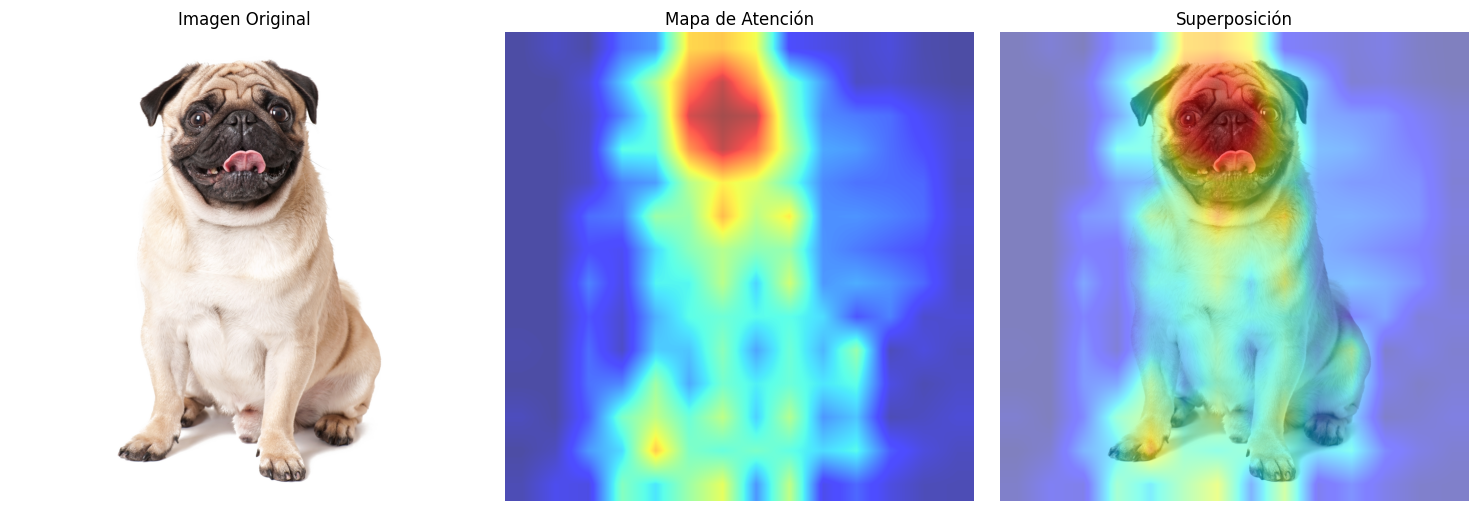


Comparando atención entre backbones...


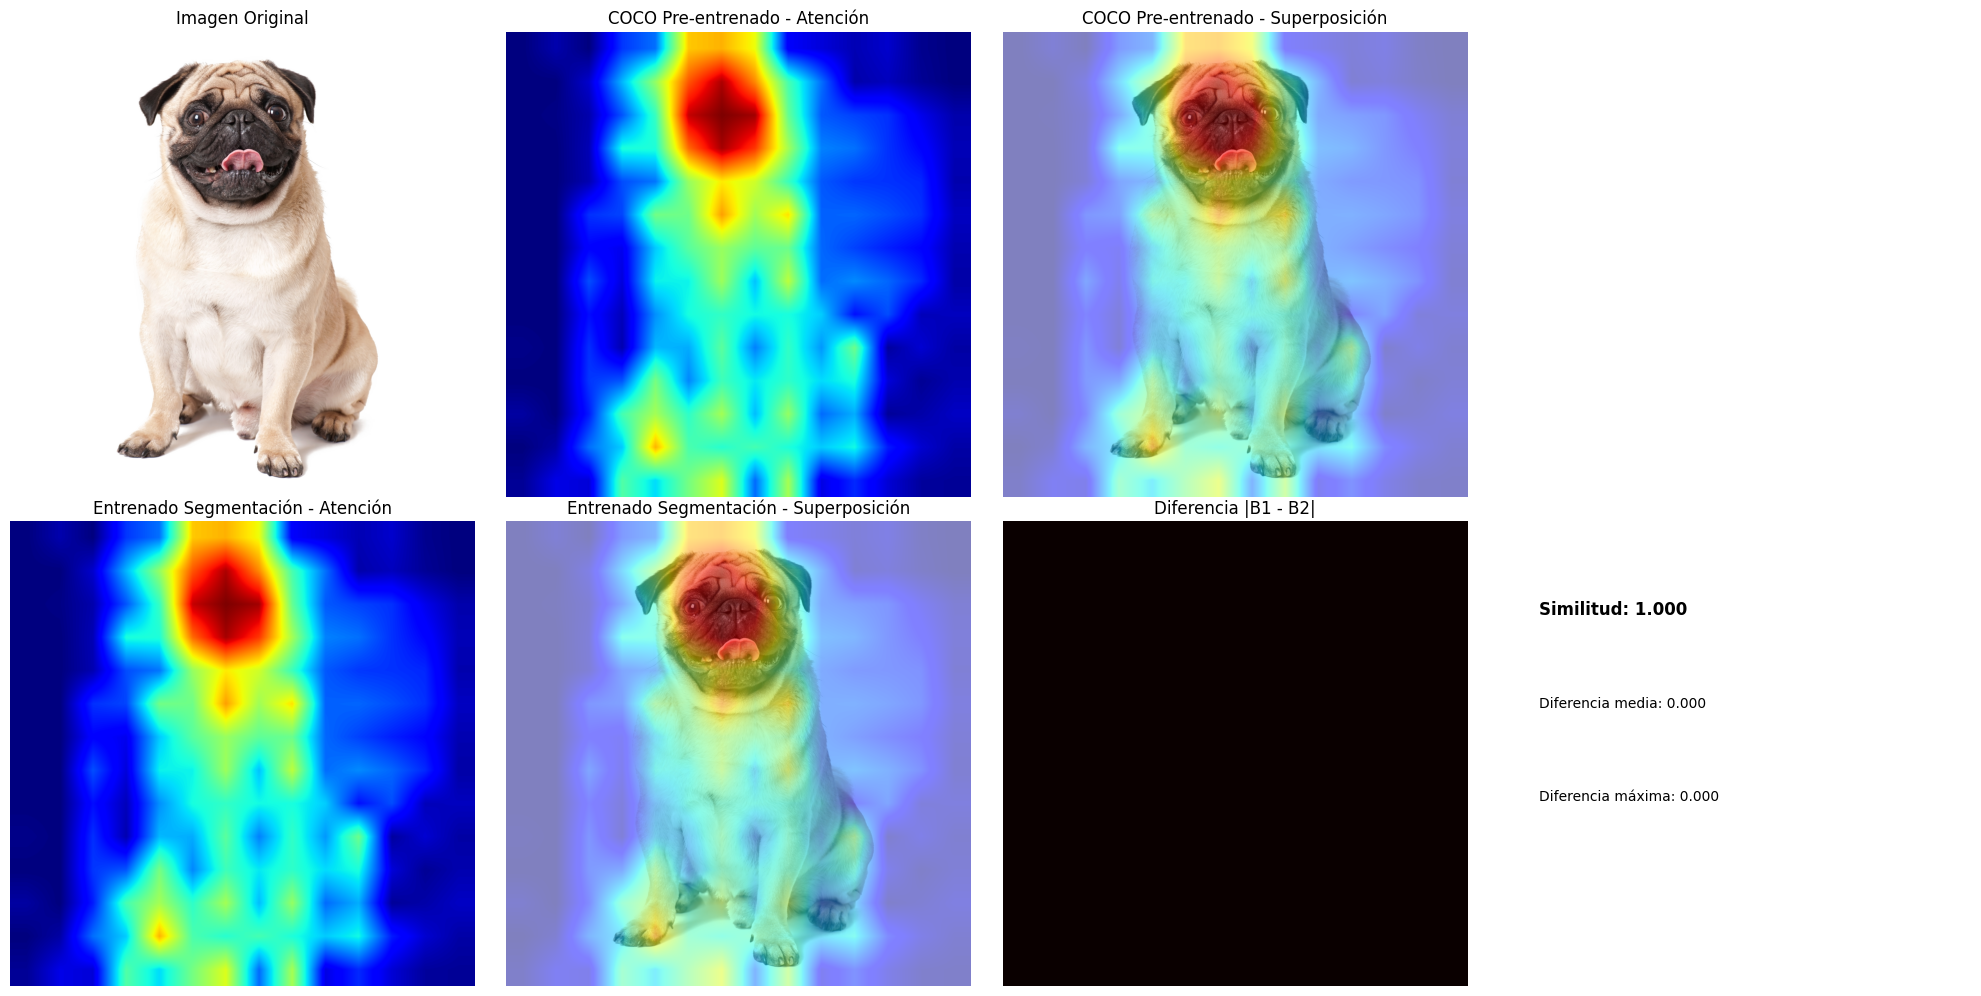


INSTRUCCIONES PARA USO AVANZADO

Para un benchmark completo de tu dataset:

1. Genera embeddings para todas las imágenes:
   embeddings, paths = embedder.get_embeddings_from_folder("assets/")

2. Organiza embeddings por categoría para comparación:
   embeddings_by_category = {}
   for i, category in enumerate(paths.keys()):
       embeddings_by_category[category] = [embeddings[i]]

3. Visualiza similitud entre vistas del mismo equipo:
   from utils import benchmark_embedding_similarity
   similarity_matrix = benchmark_embedding_similarity(
       embeddings_by_category, paths, metric='cosine'
   )

4. Para cada imagen, compara qué regiones atienden diferentes backbones:
   # El código de arriba ya hace esto automáticamente

5. Analiza los resultados:
   - Mapas de atención similares = backbones equivalentes
   - Mapas diferentes = backbones enfocan regiones distintas
   - Alta similitud en embeddings = buena agrupación de vistas



In [2]:
# EJEMPLO PRÁCTICO: VISUALIZACIÓN DE ATENCIÓN
print("\n" + "="*60)
print("EJEMPLO PRÁCTICO: VISUALIZACIÓN DE ATENCIÓN")
print("="*60)

# 1. Definir preprocessing (igual que en las clases de embeddings)
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225]),
])

# 2. Cargar modelos
print("Cargando modelos...")
vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT')
trained_backbone = load_trained_backbone('backbone_segmentation_deeplabv3_coco.pth')

# 3. Seleccionar una imagen de ejemplo
import os
image_path = "assets/vrf/pug.jpg"
if os.path.exists(f"/workspace/{image_path}"):
    print(f"✓ Usando imagen: {image_path}")

    # 4. Visualizar atención del backbone vanilla
    print("\nVisualizando atención del backbone COCO pre-entrenado...")
    try:
        from utils import visualize_embedding_attention
        visualize_embedding_attention(image_path, vanilla_model, preprocess)
    except Exception as e:
        print(f"Error en visualización: {e}")

    # 5. Comparar backbones
    print("\nComparando atención entre backbones...")
    try:
        from utils import compare_backbone_attention
        compare_backbone_attention(
            image_path,
            vanilla_model.backbone,
            trained_backbone,
            preprocess,
            "COCO Pre-entrenado",
            "Entrenado Segmentación"
        )
    except Exception as e:
        print(f"Error en comparación: {e}")

else:
    print(f"❌ Imagen no encontrada: {image_path}")
    print("Asegúrate de que la ruta sea correcta")

print("\n" + "="*60)
print("INSTRUCCIONES PARA USO AVANZADO")
print("="*60)
print("""
Para un benchmark completo de tu dataset:

1. Genera embeddings para todas las imágenes:
   embeddings, paths = embedder.get_embeddings_from_folder("assets/")

2. Organiza embeddings por categoría para comparación:
   embeddings_by_category = {}
   for i, category in enumerate(paths.keys()):
       embeddings_by_category[category] = [embeddings[i]]

3. Visualiza similitud entre vistas del mismo equipo:
   from utils import benchmark_embedding_similarity
   similarity_matrix = benchmark_embedding_similarity(
       embeddings_by_category, paths, metric='cosine'
   )

4. Para cada imagen, compara qué regiones atienden diferentes backbones:
   # El código de arriba ya hace esto automáticamente

5. Analiza los resultados:
   - Mapas de atención similares = backbones equivalentes
   - Mapas diferentes = backbones enfocan regiones distintas
   - Alta similitud en embeddings = buena agrupación de vistas
""")